In [1]:
# Gymnasium 설치 (OpenAI Gym의 최신 버전)
!pip install -q gymnasium[classic-control]
!pip install -q pygame

In [2]:
# 기본 라이브러리 임포트
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 시각화
import gymnasium as gym  # 강화학습 환경
from collections import deque, defaultdict  # 자료구조
import random  # 랜덤 샘플링

# PyTorch (DQN용)
import torch  # PyTorch 메인
import torch.nn as nn  # 신경망
import torch.optim as optim  # 옵티마이저
import torch.nn.functional as F  # 활성화 함수

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')

# 랜덤 시드 고정 (재현성)
def set_seed(seed=42):
    """모든 난수 생성기의 시드 고정"""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n 사용 디바이스: {device}")
print(f"   Gymnasium 버전: {gym.__version__}")
print(f"   PyTorch 버전: {torch.__version__}")

# 강화학습 핵심 개념
print("\n" + "=" * 60)
print("강화학습 핵심 개념")
print("=" * 60)
print("""
강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.

┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action      ┌──────┐   │
│  │Agent │ ────────────────> │ Env  │   │
│  │      │ <──────────────── │      │   │
│  └──────┘   State, Reward   └──────┘   │
│                                         │
└─────────────────────────────────────────┘

주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치
""")



 사용 디바이스: cuda
   Gymnasium 버전: 1.2.2
   PyTorch 버전: 2.9.0+cu126

강화학습 핵심 개념

강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.

┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action      ┌──────┐   │
│  │Agent │ ────────────────> │ Env  │   │
│  │      │ <──────────────── │      │   │
│  └──────┘   State, Reward   └──────┘   │
│                                         │
└─────────────────────────────────────────┘

주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치



In [4]:
# 섹션 2: Gymnasium 환경 탐색
# ========================================

# FrozenLake 환경 생성
print("\n FrozenLake-v1 환경:")
print("   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달")
print("   맵 구조:")
print("   S: 시작점 (Start)")
print("   F: 얼음 (Frozen) - 안전")
print("   H: 구멍 (Hole) - 빠지면 실패")
print("   G: 목표 (Goal)")

env_frozen = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
# is_slippery=False: 결정론적 환경 (초급용)

print(f"\n   관찰 공간 (State): {env_frozen.observation_space}")
print(f"   행동 공간 (Action): {env_frozen.action_space}")
print(f"   - 0: 왼쪽 (Left)")
print(f"   - 1: 아래 (Down)")
print(f"   - 2: 오른쪽 (Right)")
print(f"   - 3: 위 (Up)")

# 간단한 랜덤 에이전트 시뮬레이션
print("\n 랜덤 에이전트 시뮬레이션:")
state, info = env_frozen.reset(seed=42)
#  환경 초기화 (reset), state(초기 시작상태)
total_reward = 0  # 총 점수(총 보상)
steps = 0         # 수행 횟수

for step in range(20):  # 최대 20 스텝
    action = env_frozen.action_space.sample()  # 랜덤 행동(임의적인 행동을 무작위 선택)
    next_state, reward, terminated, truncated, info = env_frozen.step(action)
    # next_state 다음상태, reward (+1: 목표 달성, 0: 실패).
    # terminated (게임 성공/실패), truncated: 제한된 스텝 수(20) >> 강제 종료

    total_reward += reward
    steps += 1

    print(f"   Step {step+1}: State={state} → Action={action} → "
          f"Next State={next_state}, Reward={reward}")

    if terminated or truncated:
        print(f"  에피소드 종료! (총 보상: {total_reward}, 스텝: {steps})")
        break

    state = next_state

env_frozen.close()

# CartPole 환경 확인
print("\nCartPole-v1 환경:")
print("   목표: 막대를 수직으로 세운 채로 유지")
print("   상태: [위치, 속도, 각도, 각속도]")
print("   행동: 0=왼쪽, 1=오른쪽")
print("   보상: 매 스텝마다 +1 (최대 500)")

env_cart = gym.make('CartPole-v1', render_mode='rgb_array')
print(f"\n   관찰 공간: {env_cart.observation_space}")
print(f"   행동 공간: {env_cart.action_space}")
env_cart.close()


 FrozenLake-v1 환경:
   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달
   맵 구조:
   S: 시작점 (Start)
   F: 얼음 (Frozen) - 안전
   H: 구멍 (Hole) - 빠지면 실패
   G: 목표 (Goal)

   관찰 공간 (State): Discrete(16)
   행동 공간 (Action): Discrete(4)
   - 0: 왼쪽 (Left)
   - 1: 아래 (Down)
   - 2: 오른쪽 (Right)
   - 3: 위 (Up)

 랜덤 에이전트 시뮬레이션:
   Step 1: State=0 → Action=0 → Next State=0, Reward=0
   Step 2: State=0 → Action=2 → Next State=1, Reward=0
   Step 3: State=1 → Action=1 → Next State=5, Reward=0
  에피소드 종료! (총 보상: 0, 스텝: 3)

CartPole-v1 환경:
   목표: 막대를 수직으로 세운 채로 유지
   상태: [위치, 속도, 각도, 각속도]
   행동: 0=왼쪽, 1=오른쪽
   보상: 매 스텝마다 +1 (최대 500)

   관찰 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   행동 공간: Discrete(2)



섹션 3: FrozenLake Q-learning

 Q-learning 개념:

Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.

Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

- r (reward) : 즉각적인 보상 
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)


 FrozenLake Q-learning 학습 시작:
   Episode 200/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.367
   Episode 400/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.135
   Episode 600/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.049
   Episode 800/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.018
   Episode 1000/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.010
   Episode 1200/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.010
   Episode 1400/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.010
   Episode 1600/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.010
   Episode 1800/2000 - Avg Reward: 0.000, Success Rate: 0.0%, ε: 0.010
   Episode 2000/2000 - Avg Reward: 

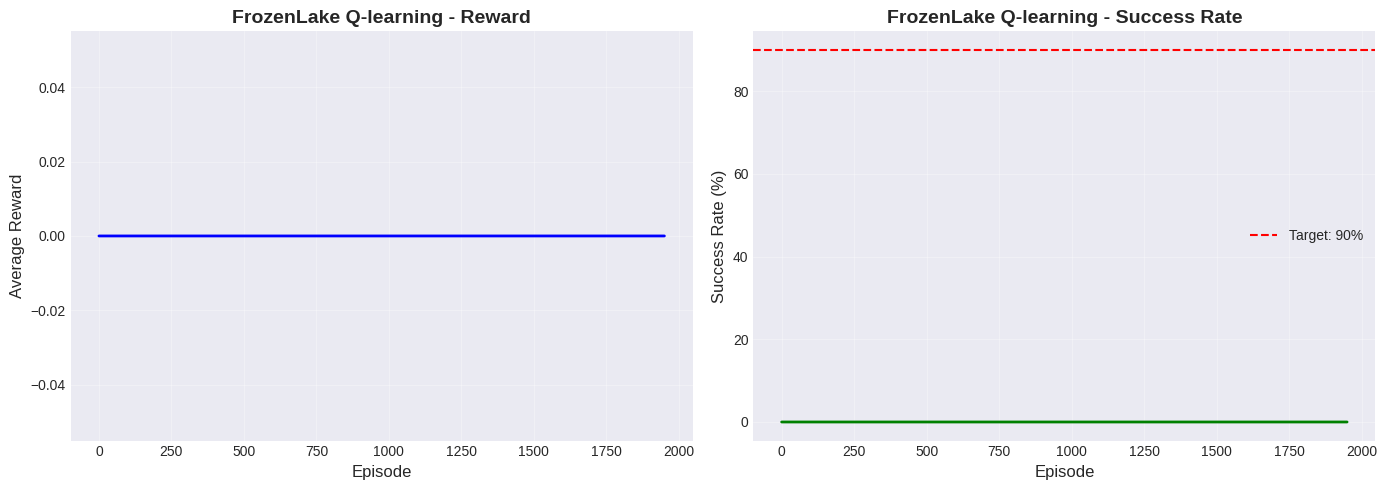

 결과 저장: frozenlake_qlearning_results.png


In [6]:
# ========================================
# 섹션 3: FrozenLake Q-learning
# ========================================
print("\n" + "=" * 60)
print("섹션 3: FrozenLake Q-learning")
print("=" * 60)

print("\n Q-learning 개념:")
print("""
Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.

Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

- r (reward) : 즉각적인 보상
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)
""")

# Q-learning Agent 클래스
class QLearningAgent:
    """
    Q-learning 에이전트
    테이블 기반으로 Q-value를 저장하고 업데이트
    이 agent 각 (상태-행동, state-action) 쌍 >> Q-value 를 2차원 배열 테이블 형태로 저장
    """
    def __init__(self, n_states, n_actions, learning_rate=0.1,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01):
        """
        Args:
            n_states: 상태 개수
            n_actions: 행동 개수
            learning_rate: 학습률 (α)
            discount_factor: 할인율 (γ)
            epsilon: 초기 탐험 비율 (ε)
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
        """
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table 초기화 (모든 값을 0으로)
        self.q_table = np.zeros((n_states, n_actions))

    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험(Exploration): 랜덤 행동
        if np.random.random() < self.epsilon:
            # random.random() >> [0,1] 무작위로(임의의) 수 하나 뽑기
            return np.random.randint(self.n_actions)
        # 활용(Exploitation): 최고 Q-value 행동
        else:
            return np.argmax(self.q_table[state])
            # q table에서 가장 값이 큰 행동(현재까지 있는 선택지에서 가장 좋아보이는 행동) 선택

    def update(self, state, action, reward, next_state, done):
        """
        Q-value 업데이트
        Args:
            state: 현재 상태
            action: 수행한 행동
            reward: 받은 보상
            next_state: 다음 상태
            done: 에피소드 종료 여부
        """
        # 현재 Q-value
        current_q = self.q_table[state, action]

        # TD(Time Difference) Target 계산
        if done:   # 에피소드가 종료
            target = reward
            # 종료 상태는 미래 보상 없음
            # 지금 받는 reward 만 target(목표) 됨
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])


        # Q-value 업데이트 (TD Error 기반)
        td_error = target - current_q
        # 목표(target) - 현재 값(current_q)
        self.q_table[state, action] += self.lr * td_error
        # td_error (시간차 오차)에 학습률(lr) 곱해서 기존 q값에 더해줌
        # >> 점점 더 좋은 값으로 수렴

    def decay_epsilon(self):
        """ε 감소 (탐험 비율 줄이기)"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        # epsilon이 epsilon_min보다 너무 작아지지 않게 하기 위해서 max() 써서 epsilon 업데이트 함

# FrozenLake Q-learning 학습
print("\n FrozenLake Q-learning 학습 시작:")

# 환경 및 에이전트 생성
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
agent = QLearningAgent(
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01
)

# 학습 설정
n_episodes = 2000  # 에피소드 수 (2000번 게임 다시 시작하면서 학습)
max_steps = 100  # 에피소드당 최대 스텝 (1 게임마다 최대 100번까지 움직일 수 있음)

# 학습 통계 저장
rewards_history = []
success_history = []

# 학습 루프
for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0

    for step in range(max_steps):
        # 행동 선택
        action = agent.get_action(state)

        # 환경에서 행동 수행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-value 업데이트
        agent.update(state, action, reward, next_state, done)

        episode_reward += reward
        state = next_state

        if done:
            break

    # ε 감소
    agent.decay_epsilon()

    # 통계 기록
    rewards_history.append(episode_reward)
    success_history.append(1 if episode_reward > 0 else 0)

    # 200 에피소드마다 진행상황 출력
    if (episode + 1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        # rewards_history[-100:] 최근 100에피소드
        success_rate = np.mean(success_history[-100:]) * 100
        print(f"   Episode {episode+1}/{n_episodes} - "
              f"Avg Reward: {avg_reward:.3f}, "
              f"Success Rate: {success_rate:.1f}%, "
              f"ε: {agent.epsilon:.3f}")

env.close()
print("\n FrozenLake Q-learning 학습 완료!")

# 학습된 Q-table 시각화
print("\n 학습된 Q-table (처음 8개 상태):")
print(agent.q_table[:8])

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 보상 그래프
window = 50
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_smooth, linewidth=2, color='blue')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('FrozenLake Q-learning - Reward', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 성공률 그래프
success_smooth = np.convolve(success_history, np.ones(window)/window, mode='valid') * 100
axes[1].plot(success_smooth, linewidth=2, color='green')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Success Rate (%)', fontsize=12)
axes[1].set_title('FrozenLake Q-learning - Success Rate', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=90, color='red', linestyle='--', label='Target: 90%')
axes[1].legend()

plt.tight_layout()
plt.savefig('frozenlake_qlearning_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" 결과 저장: frozenlake_qlearning_results.png")

In [7]:
# ========================================
# 섹션 4: CartPole 환경 이해
# ========================================
print("\n" + "=" * 60)
print("섹션 4: CartPole 환경 이해")
print("=" * 60)

print("\nCartPole 환경 상세:")
print("""
CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.

상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞

행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기

보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝

종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)
""")

# CartPole 환경 생성 및 확인
env = gym.make('CartPole-v1', render_mode=None)
state, info = env.reset(seed=42)

print(f"\ 초기 상태 예시:")
print(f"   {state}")
print(f"   [위치, 속도, 각도, 각속도]")

# 랜덤 에이전트로 CartPole 시뮬레이션
print("\n랜덤 에이전트 시뮬레이션:")
episode_rewards = []

for episode in range(5):
    state, info = env.reset()
    episode_reward = 0

    for step in range(500):
        action = env.action_space.sample()  # 랜덤 행동
        state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(episode_reward)
    print(f"   Episode {episode+1}: Reward = {episode_reward}")

print(f"\n   평균 보상: {np.mean(episode_rewards):.1f}")
print("   → 랜덤 정책은 평균 20-30 정도의 보상")

env.close()


섹션 4: CartPole 환경 이해

CartPole 환경 상세:

CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.

상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞

행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기

보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝

종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)

\ 초기 상태 예시:
   [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
   [위치, 속도, 각도, 각속도]

랜덤 에이전트 시뮬레이션:
   Episode 1: Reward = 18.0
   Episode 2: Reward = 20.0
   Episode 3: Reward = 22.0
   Episode 4: Reward = 15.0
   Episode 5: Reward = 11.0

   평균 보상: 17.2
   → 랜덤 정책은 평균 20-30 정도의 보상


<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-4118501274.py:39: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ 초기 상태 예시:")


In [8]:
# ========================================
# 섹션 5: DQN 네트워크 구성
# ========================================
print("\n" + "=" * 60)
print("섹션 5: DQN (Deep Q-Network) 구성")
print("=" * 60)

print("\nDQN 개념:")
print("""
DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.

핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 사용

DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  예: [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘
""")

# DQN 신경망 정의
class DQN(nn.Module):
    """
    DQN 신경망 (Fully Connected)
    State를 입력받아 각 Action의 Q-value 출력
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        """
        Args:
            state_dim: 상태 차원
            action_dim: 행동 개수
            hidden_dim: 은닉층 뉴런 수
        """
        super(DQN, self).__init__()

        # 3층 Fully Connected Network
        self.fc1 = nn.Linear(state_dim, hidden_dim)  # 입력층 → 은닉층1
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 은닉층1 → 은닉층2
        self.fc3 = nn.Linear(hidden_dim, action_dim)  # 은닉층2 → 출력층

    def forward(self, x):
        """
        Forward pass
        Args:
            x: 상태 텐서
        Returns:
            Q-values: 각 행동의 Q-value
        """
        x = F.relu(self.fc1(x))  # ReLU 활성화
        x = F.relu(self.fc2(x))  # ReLU 활성화
        q_values = self.fc3(x)   # 출력 (활성화 함수 없음)
        return q_values

# 네트워크 구조 확인
print("\n DQN 네트워크 구조:")
sample_network = DQN(state_dim=4, action_dim=2, hidden_dim=128)
print(sample_network)

# 파라미터 수 계산
total_params = sum(p.numel() for p in sample_network.parameters())
print(f"\n   총 파라미터 수: {total_params:,}개")

# Experience Replay Buffer
class ReplayBuffer:
    """
    경험 재생 버퍼
    과거 경험(transition)을 저장하고 랜덤 샘플링
    """
    def __init__(self, capacity):
        """
        Args:
            capacity: 버퍼 최대 크기(최대 기억용량)
        """
        self.buffer = deque(maxlen=capacity)  # 최대 크기 제한
        # deque : 꽉차면 제일 오래된 기억부터 자동으로 지워짐

    def push(self, state, action, reward, next_state, done):
        """
        경험 저장
        Args:
            state: 현재 상태
            action: 수행한 행동
            reward: 받은 보상
            next_state: 다음 상태
            done: 종료 여부
        """
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        랜덤 샘플링
        Args:
            batch_size: 샘플 개수
        Returns:
            batch: (state, action, reward, next_state, done) 튜플들
        """
        batch = random.sample(self.buffer, batch_size)

        # 배치를 텐서로 변환
        states = torch.FloatTensor([t[0] for t in batch])
        actions = torch.LongTensor([t[1] for t in batch])
        rewards = torch.FloatTensor([t[2] for t in batch])
        next_states = torch.FloatTensor([t[3] for t in batch])
        dones = torch.FloatTensor([t[4] for t in batch])

        return states, actions, rewards, next_states, dones

    def __len__(self):
        """버퍼 크기 반환"""
        return len(self.buffer)

print("\n Experience Replay Buffer:")
print("   - 과거 경험을 저장하여 학습에 재사용")
print("   - 데이터 효율성 향상")
print("   - 연속된 경험의 상관관계 제거")


섹션 5: DQN (Deep Q-Network) 구성

DQN 개념:

DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.

핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 사용

DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  예: [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘


 DQN 네트워크 구조:
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

   총 파라미터 수: 17,410개

 Experience Replay Buffer:
   - 과거 경험을 저장하여 학습에 재사용
   - 데이터 효율성 향상
   - 연속된 경험의 상관관계 제거


In [9]:
# ========================================
# 섹션 6: CartPole DQN 학습
# ========================================
print("\n" + "=" * 60)
print("섹션 6: CartPole DQN 학습")
print("=" * 60)

# DQN Agent 클래스
class DQNAgent:
    """
    DQN 에이전트
    네트워크 학습 및 행동 선택 담당
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128,
                 lr=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01, buffer_size=10000, batch_size=64):
        """
        Args:
            state_dim: 상태 차원
            action_dim: 행동 개수
            hidden_dim: 은닉층 크기
            lr: 학습률
            gamma: 할인율
            epsilon: 초기 탐험 비율
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
            buffer_size: Replay Buffer 크기
            batch_size: 미니배치 크기
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size

        # Q-Network (학습용)
        self.q_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        # Target Network (타겟 계산용) : 가끔씩만 업데이트 해야 함
        self.target_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()  # 평가 모드

        # 옵티마이저 및 손실 함수
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        # Replay Buffer
        self.memory = ReplayBuffer(buffer_size)

    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        # 활용
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_tensor)
            action = q_values.argmax().item()
        return action

    def train(self):
        """
        미니배치 학습
        Returns:
            loss: 학습 손실
        """
        # 버퍼에 충분한 데이터가 없으면 학습 안함
        if len(self.memory) < self.batch_size:
            return 0.0

        # 미니배치 샘플링
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)

        # 현재 Q-values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        # actions.unsqueeze(1) (batch_size, 1)
        # >> q_network(states) 때문에 (batch_size, n_actions)
        # gather(1, ...) : 열방향

        # 타겟 Q-values (Target Network 사용)
        with torch.no_grad():
            max_next_q_values = self.target_network(next_states).max(1)[0]
            # max(1)[0] : (batch_size, n_actions) 에서 1(열방향, n_actions) 에 대해 최대값 구하고 그 인덱스 구하기
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        # 손실 계산 및 역전파
        loss = self.loss_fn(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Target Network를 Q-Network로 업데이트"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """ε 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# CartPole 환경 및 에이전트 생성
print("\n CartPole DQN 학습 시작:")

env = gym.make('CartPole-v1', render_mode=None)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=128,
    lr=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    buffer_size=10000,
    batch_size=64
)

print(f"\n 학습 설정:")
print(f"   State Dim: {state_dim}")
print(f"   Action Dim: {action_dim}")
print(f"   Hidden Dim: 128")
print(f"   Learning Rate: 0.001")
print(f"   Buffer Size: 10,000")
print(f"   Batch Size: 64")

# 학습 설정
n_episodes = 500
target_update_freq = 10  # 10 에피소드마다 Target Network 업데이트

# 학습 통계
rewards_history = []
losses_history = []

# 학습 루프
for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0
    episode_loss = 0
    steps = 0

    for step in range(500):  # 최대 500 스텝
        # 행동 선택
        action = agent.get_action(state)

        # 환경에서 행동 수행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Replay Buffer에 저장
        agent.memory.push(state, action, reward, next_state, done)

        # 학습
        loss = agent.train()
        episode_loss += loss

        episode_reward += reward
        state = next_state
        steps += 1

        if done:
            break

    # ε 감소
    agent.decay_epsilon()

    # Target Network 업데이트
    if (episode + 1) % target_update_freq == 0:
        agent.update_target_network()

    # 통계 저장
    rewards_history.append(episode_reward)
    losses_history.append(episode_loss / steps if steps > 0 else 0)

    # 50 에피소드마다 진행상황 출력
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(rewards_history[-50:])
        avg_loss = np.mean(losses_history[-50:])
        print(f"   Episode {episode+1}/{n_episodes} - "
              f"Avg Reward: {avg_reward:.1f}, "
              f"Avg Loss: {avg_loss:.4f}, "
              f"ε: {agent.epsilon:.3f}")

env.close()
print("\n  CartPole DQN 학습 완료!")

# 최종 성능
final_avg_reward = np.mean(rewards_history[-50:])
print(f"\n최종 50 에피소드 평균 보상: {final_avg_reward:.1f}")
if final_avg_reward >= 450:
    print("    우수! CartPole을 성공적으로 해결했습니다!")
elif final_avg_reward >= 300:
    print("    양호! 더 학습하면 성능이 향상될 수 있습니다.")
else:
    print("    학습 중... 에피소드를 늘리면 성능이 향상됩니다.")



섹션 6: CartPole DQN 학습

 CartPole DQN 학습 시작:

 학습 설정:
   State Dim: 4
   Action Dim: 2
   Hidden Dim: 128
   Learning Rate: 0.001
   Buffer Size: 10,000
   Batch Size: 64


/tmp/ipython-input-4158740454.py:103: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor([t[0] for t in batch])


   Episode 50/500 - Avg Reward: 23.2, Avg Loss: 0.1143, ε: 0.778
   Episode 100/500 - Avg Reward: 35.8, Avg Loss: 0.1939, ε: 0.606
   Episode 150/500 - Avg Reward: 67.0, Avg Loss: 0.2894, ε: 0.471
   Episode 200/500 - Avg Reward: 86.9, Avg Loss: 0.4270, ε: 0.367
   Episode 250/500 - Avg Reward: 84.8, Avg Loss: 0.5736, ε: 0.286
   Episode 300/500 - Avg Reward: 120.4, Avg Loss: 0.7450, ε: 0.222
   Episode 350/500 - Avg Reward: 150.3, Avg Loss: 0.7283, ε: 0.173
   Episode 400/500 - Avg Reward: 167.8, Avg Loss: 0.4849, ε: 0.135
   Episode 450/500 - Avg Reward: 211.4, Avg Loss: 0.2745, ε: 0.105
   Episode 500/500 - Avg Reward: 204.5, Avg Loss: 0.5207, ε: 0.082

  CartPole DQN 학습 완료!

최종 50 에피소드 평균 보상: 204.5
    학습 중... 에피소드를 늘리면 성능이 향상됩니다.


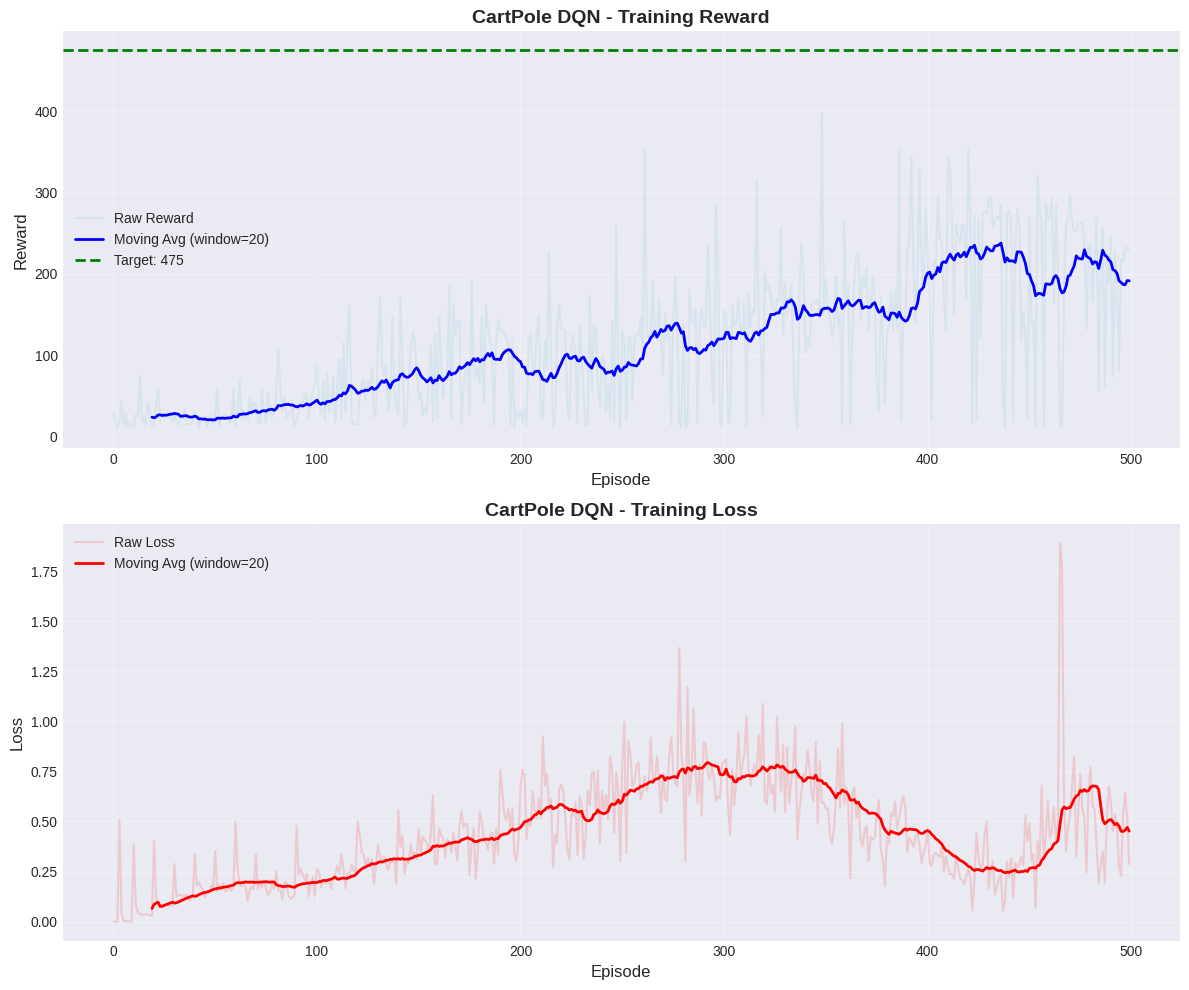


학습 결과 저장: cartpole_dqn_training.png


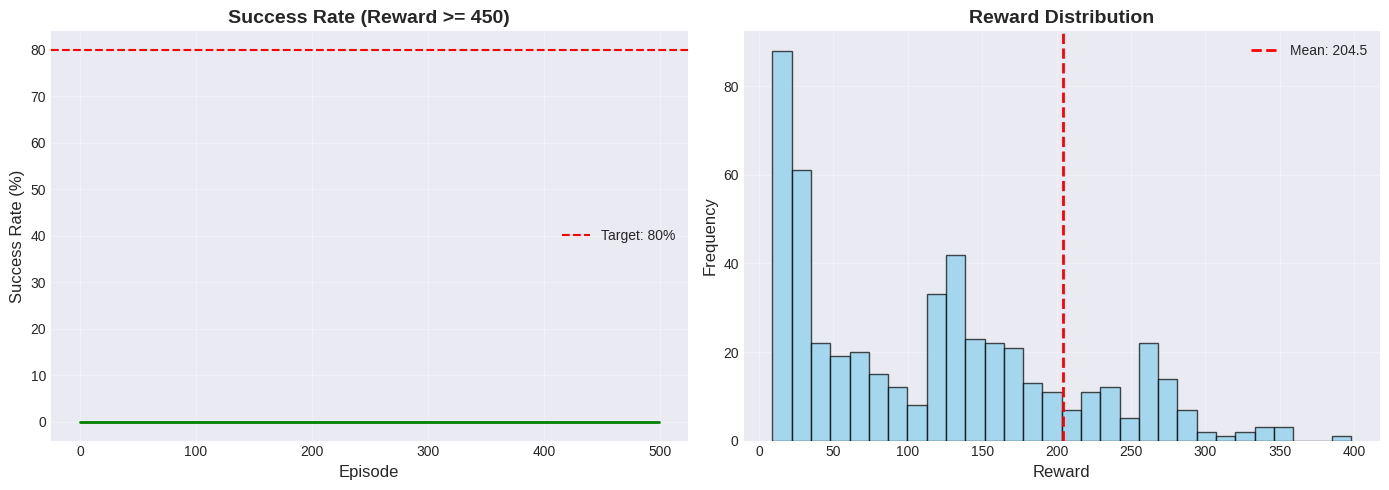

통계 그래프 저장: cartpole_dqn_stats.png


In [10]:
# ========================================
# 섹션 7: 결과 시각화
# ========================================
# 학습 결과 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 보상 그래프
window = 20
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_history, alpha=0.3, color='lightblue', label='Raw Reward')
axes[0].plot(range(window-1, len(rewards_history)), rewards_smooth,
            linewidth=2, color='blue', label=f'Moving Avg (window={window})')
axes[0].axhline(y=475, color='green', linestyle='--', linewidth=2, label='Target: 475')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Reward', fontsize=12)
axes[0].set_title('CartPole DQN - Training Reward', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실 그래프
loss_smooth = np.convolve(losses_history, np.ones(window)/window, mode='valid')
axes[1].plot(losses_history, alpha=0.3, color='lightcoral', label='Raw Loss')
axes[1].plot(range(window-1, len(losses_history)), loss_smooth,
            linewidth=2, color='red', label=f'Moving Avg (window={window})')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('CartPole DQN - Training Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cartpole_dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n학습 결과 저장: cartpole_dqn_training.png")

# 성능 통계 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 에피소드별 성공률 (보상 >= 450)
success_threshold = 450
success_mask = np.array(rewards_history) >= success_threshold
success_rate = [np.mean(success_mask[max(0, i-50):i+1]) * 100
                for i in range(len(success_mask))]

axes[0].plot(success_rate, linewidth=2, color='green')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Success Rate (%)', fontsize=12)
axes[0].set_title('Success Rate (Reward >= 450)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=80, color='red', linestyle='--', label='Target: 80%')
axes[0].legend()

# 보상 분포 히스토그램
axes[1].hist(rewards_history, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=final_avg_reward, color='red', linestyle='--',
               linewidth=2, label=f'Mean: {final_avg_reward:.1f}')
axes[1].set_xlabel('Reward', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Reward Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cartpole_dqn_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("통계 그래프 저장: cartpole_dqn_stats.png")


In [11]:
# ========================================
# 섹션 8: 학습 정리 및 요약
# ========================================
print("\n" + "=" * 60)
print("섹션 8: 학습 정리")
print("=" * 60)

print("\n 실습 완료!")
print("\n학습한 내용:")
print("   강화학습 기본 개념 (State, Action, Reward, Policy)")
print("   MDP (Markov Decision Process)")
print("   Q-learning (FrozenLake)")
print("   Deep Q-Network (CartPole)")
print("   Experience Replay & Target Network")

print("\n 실습 결과 요약:")
print(f"   1. FrozenLake Q-learning:")
print(f"      - 최종 성공률: {success_smooth[-1]:.1f}%")
print(f"   2. CartPole DQN:")
print(f"      - 최종 평균 보상: {final_avg_reward:.1f}")
print(f"      - 최고 보상: {max(rewards_history):.0f}")


섹션 8: 학습 정리

 실습 완료!

학습한 내용:
   강화학습 기본 개념 (State, Action, Reward, Policy)
   MDP (Markov Decision Process)
   Q-learning (FrozenLake)
   Deep Q-Network (CartPole)
   Experience Replay & Target Network

 실습 결과 요약:
   1. FrozenLake Q-learning:
      - 최종 성공률: 0.0%
   2. CartPole DQN:
      - 최종 평균 보상: 204.5
      - 최고 보상: 398
